<a href="https://colab.research.google.com/github/vsauldba/python-data-analytics/blob/main/NYC_public_school_students_achievement_on_Regents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [99]:
from IPython.display import Image, display
display(Image(filename='Projecttitle.png',width=1000))

FileNotFoundError: [Errno 2] No such file or directory: 'Projecttitle.png'

In [100]:

#Assessment of NYC Public Schools Student's achievement on Regents Exam Performance Analysis
#1-Objective
#The purpose of this project is to analyze student Regents test performance in New York City public schools.
#I will select one school and one performance measure, then compare the school's results with another group of schools.

In [101]:

#Load the required libraries
import pandas as pd
import matplotlib.pyplot as plt


In [102]:
#Import the Dataset

url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv"

df = pd.read_csv(url)

# Inspect the Loaded Data
df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [103]:
# Examine the Dataset Dimensions
df.shape

(212331, 15)

The dataset has 212331 Rows and 15 Columns

In [104]:
# Check the Columns Name
df.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

First, I explored the dataset to get a better understanding of the data. I checked the number of rows and columns, reviewed the column names and examined the overall structure of the dataset.

In [105]:
#Check the Structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212331 entries, 0 to 212330
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   School DBN                   212331 non-null  object
 1   School Name                  212331 non-null  object
 2   School Level                 212331 non-null  object
 3   Regents Exam                 212321 non-null  object
 4   Year                         212331 non-null  int64 
 5   Total Tested                 212331 non-null  int64 
 6   Mean Score                   212331 non-null  object
 7   Number Scoring Below 65      212331 non-null  object
 8   Percent Scoring Below 65     212331 non-null  object
 9   Number Scoring 65 or Above   212331 non-null  object
 10  Percent Scoring 65 or Above  212331 non-null  object
 11  Number Scoring 80 or Above   212331 non-null  object
 12  Percent Scoring 80 or Above  212331 non-null  object
 13  Number Scoring

In [106]:
# Examine the Data Type of Each Column
df.dtypes

,0
School DBN,object
School Name,object
School Level,object
Regents Exam,object
Year,int64
Total Tested,int64
Mean Score,object
Number Scoring Below 65,object
Percent Scoring Below 65,object
Number Scoring 65 or Above,object


I used df.info() to review the overall structure of the dataset, including non-null values and data types. Then, i used df.dtypes to examine the data types of each columns more clearly.

In [107]:
#6- Examine Missing Values
df.isnull().sum()


,0
School DBN,0
School Name,0
School Level,0
Regents Exam,10
Year,0
Total Tested,0
Mean Score,0
Number Scoring Below 65,0
Percent Scoring Below 65,0
Number Scoring 65 or Above,0


No Missing Values, meaning their data is complete. However, the Regents exam columns contained 10 missing values, which may require further investigation or cleaning.

In [108]:
# Investigation of 10 records
df[df['Regents Exam'].isnull()]

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
18654,84M478,Inwood Academy for Leadership Charter School,Secondary School,NaN,2015,90,55.6,61,67.8,29,32.2,6,6.7,0,0
52756,84M478,Inwood Academy for Leadership Charter School,Secondary School,NaN,2015,81,55.9,55,67.9,26,32.1,5,6.2,0,0
52757,84M478,Inwood Academy for Leadership Charter School,Secondary School,NaN,2015,9,53.4,6,66.7,3,33.3,1,11.1,0,0
100865,84M478,Inwood Academy for Leadership Charter School,Secondary School,NaN,2015,5,s,s,s,s,s,s,s,na,na
100866,84M478,Inwood Academy for Leadership Charter School,Secondary School,NaN,2015,54,57.4,34,63,20,37,6,11.1,0,0
100867,84M478,Inwood Academy for Leadership Charter School,Secondary School,NaN,2015,31,s,s,s,s,s,s,s,na,na
138300,84M478,Inwood Academy for Leadership Charter School,Secondary School,NaN,2015,54,57.3,34,63,20,37,5,9.3,0,0
138301,84M478,Inwood Academy for Leadership Charter School,Secondary School,NaN,2015,36,53.2,27,75,9,25,1,2.8,0,0
209785,84M478,Inwood Academy for Leadership Charter School,Secondary School,NaN,2015,12,59,9,75,3,25,1,8.3,0,0
209786,84M478,Inwood Academy for Leadership Charter School,Secondary School,NaN,2015,78,55.1,52,66.7,26,33.3,5,6.4,0,0


In [109]:
#7- Data Cleaning view of the Dataset
df.isnull().sum().sort_values(ascending=False)

,0
Regents Exam,10
School Name,0
School DBN,0
School Level,0
Year,0
Total Tested,0
Mean Score,0
Number Scoring Below 65,0
Percent Scoring Below 65,0
Number Scoring 65 or Above,0


I Checked for missing values in the dataset and sorted them from highest to lowest. The results showed that the regents Exam column has 10 missing values, while the other columns have no missing values.

In [110]:
#8- Check Duplicate Rows
df.duplicated().sum()

np.int64(23819)

This datatset contains 23819 duplicates rows.

In [111]:
#9- Remove Duplicate Rows
df=df.drop_duplicates()


I removed the duplicate rows from the dataset

In [112]:
# 10- View School Names
df['School Name'].unique()

array(['P.S. 034 Franklin D. Roosevelt', 'P.S. 140 Nathan Straus',
       'P.S. 184m Shuang Wen', ..., 'Family Life Academy Charter School',
       'Harriet Tubman Charter School', 'Icahn Charter School'],
      dtype=object)

I viewed the unique school names to see the different schools included in the dataset.

9.Selecting a School for Analysis
To select a school for this analysis, I calculated the average Regents Mean Score for each school and reviewed the schools with the highest averages.

In [113]:
#Checking  the data type of the " Mean Score" colum before performing calculations.
df["Mean Score"] = pd.to_numeric(df["Mean Score"], errors="coerce")

#Check the data type of the "Mean Score" Column
df["Mean Score"].dtype

dtype('float64')

The result "float64" confirms that the mean score column is numeric and ready for calculations such as averages.

In [114]:
#10- Calculate Each School Average
school_average = df.groupby("School Name")["Mean Score"].mean()
school_average.head(10)


,Mean Score
School Name,
47 The American Sign Language and English Secondar,61.072637
A. Philip Randolph Campus High School,65.656667
ACORN Community High School,59.993158
Abraham Lincoln High School,61.565423
Abraham Lincoln Yabc,57.846795
Academy For Personal Leadership And Excellence,68.515625
Academy for Careers in Television and Film,69.453412
Academy for College Preparation and Career Explora,59.985897
Academy for Conservation and the Environment,58.612705


In [115]:
#10- Check the number of Records for Each School
school_count = df["School Name"].value_counts()
school_count.head(10)

,count
School Name,
New Visions Charter High School for Advanced Math,1239
New Visions Charter High School for the Humanities,943
Edward R. Murrow High School,487
James Madison High School,486
John Dewey High School,486
Francis Lewis High School,485
Long Island City High School,482
Forest Hills High School,480
Tottenville High School,478


I checked the number of records for each school to identufy schools with enough data for further analysis.

In [116]:
# Created the School summary
school_summary = df.groupby("School Name")["Mean Score"].agg(
    Average_Score="mean",
    Number_of_Records="count"
)

school_summary.head()

,Average_Score,Number_of_Records
School Name,,
47 The American Sign Language and English Secondar,61.072637,201
A. Philip Randolph Campus High School,65.656667,360
ACORN Community High School,59.993158,190
Abraham Lincoln High School,61.565423,402
Abraham Lincoln Yabc,57.846795,156


Filtering for schools with at least 40 valid score records:

In [117]:
school_summary = school_summary[
    school_summary["Number_of_Records"] >= 40
]

In [118]:
school_summary = school_summary.sort_values(
    "Average_Score",
    ascending=False
)

school_summary.head(10)

,Average_Score,Number_of_Records
School Name,,
Stuyvesant High School,91.705926,270
J.H.S. 185 Edward Bleeker,91.593182,44
J.H.S. 074 Nathaniel Hawthorne,90.190476,63
Bronx High School of Science,90.171429,329
J.H.S. 167 Robert F. Wagner,89.834146,41
Townsend Harris High School,89.722848,302
I.S. 98 Bay Academy,89.347887,71
J.H.S. 190 Russell Sage,89.344898,49
High School of American Studies at Lehman College,89.029665,209


I calculated the average Mean Score and number of valid score records for each school. I focused on schools with at least 40 valid records and displays the 10 schools with the highest average score among schools meeting so that the selected school's average was based on a reasonable amount of data.

In [119]:
# 11-Select a School for further analysis
selected_school = school_summary.index[0]

selected_school

'Stuyvesant High School'

In [120]:
school_summary.loc[selected_school]

,Stuyvesant High School
Average_Score,91.705926
Number_of_Records,270.000000


In [121]:
selected_school_df = df[
    df["School Name"] == selected_school
].copy()

selected_school_df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
1511,02M475,Stuyvesant High School,High school,Algebra2/Trigonometry,2015,875,92.9,8,0.9,867,99.1,819,93.6,819,93.6
1512,02M475,Stuyvesant High School,High school,Algebra2/Trigonometry,2016,792,93.1,5,0.6,787,99.4,743,93.8,743,93.8
1513,02M475,Stuyvesant High School,High school,Common Core Algebra,2015,35,82.3,0,0,35,100,20,57.1,34,97.1
1514,02M475,Stuyvesant High School,High school,Common Core Algebra,2016,144,89.5,0,0,144,100,142,98.6,144,100
1515,02M475,Stuyvesant High School,High school,Common Core Algebra,2017,63,93.9,0,0,63,100,63,100,63,100


The school with the highest average is: Stuyvesant High School

In [122]:
#Examine the Regents Exam for the selected school
selected_school_df["Regents Exam"].unique()

array(['Algebra2/Trigonometry', 'Common Core Algebra',
       'Common Core Algebra2', 'Common Core English',
       'Common Core Geometry', 'English', 'Geometry',
       'Global History and Geography', 'Integrated Algebra',
       'Living Environment', 'Physical Settings/Chemistry',
       'Physical Settings/Physics', 'U.S. History and Government'],
      dtype=object)

After selecting  "Stuyvesant High School", I examined the unique Regents exam in the school's data to identify the different subjects included in the analysis.

In [123]:
# Choose Exam
selected_school_df["Regents Exam"].unique()

array(['Algebra2/Trigonometry', 'Common Core Algebra',
       'Common Core Algebra2', 'Common Core English',
       'Common Core Geometry', 'English', 'Geometry',
       'Global History and Geography', 'Integrated Algebra',
       'Living Environment', 'Physical Settings/Chemistry',
       'Physical Settings/Physics', 'U.S. History and Government'],
      dtype=object)

Filter the choosen school

In [124]:
chosen_school = "Stuyvesant High School"
school_data = df[df["School Name"] == chosen_school]
school_data.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
1511,02M475,Stuyvesant High School,High school,Algebra2/Trigonometry,2015,875,92.9,8,0.9,867,99.1,819,93.6,819,93.6
1512,02M475,Stuyvesant High School,High school,Algebra2/Trigonometry,2016,792,93.1,5,0.6,787,99.4,743,93.8,743,93.8
1513,02M475,Stuyvesant High School,High school,Common Core Algebra,2015,35,82.3,0,0,35,100,20,57.1,34,97.1
1514,02M475,Stuyvesant High School,High school,Common Core Algebra,2016,144,89.5,0,0,144,100,142,98.6,144,100
1515,02M475,Stuyvesant High School,High school,Common Core Algebra,2017,63,93.9,0,0,63,100,63,100,63,100


THE Dataset is focused only on the chosen school to make the analysis more specific and easier to understand. This allow us to examine the school's exam scores and overall performance more closely.

In [125]:
# 11- Check how much data the shool has
school_data.shape

(361, 15)

The selected school has 361 records and 15 columns, providing enough data for further analysis.

In [126]:
#11-Looking of Exams Scores.
school_data.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

In [127]:
#12- Examination of Exams Scores
# View the exam name, year, number of students tested, and mean score
school_data[['Regents Exam', 'Year', 'Total Tested', 'Mean Score']].head(10)

,Regents Exam,Year,Total Tested,Mean Score
1511,Algebra2/Trigonometry,2015,875,92.9
1512,Algebra2/Trigonometry,2016,792,93.1
1513,Common Core Algebra,2015,35,82.3
1514,Common Core Algebra,2016,144,89.5
1515,Common Core Algebra,2017,63,93.9
1516,Common Core Algebra2,2016,785,84.2
1517,Common Core Algebra2,2017,796,87.3
1518,Common Core English,2016,828,92.4
1519,Common Core English,2017,824,93.9
1520,Common Core Geometry,2015,785,91.5


In [128]:
#13- Calculate the Average Mean SCore
# Calculate the overall average mean score for the selected school
average_score = school_data['Mean Score'].mean()
round(average_score, 2)


np.float64(91.71)

The Selected School Overall Average Regents exam score is 91.71

In [129]:
#14-Average Score by regents exams
#Calculate the average score for each Regents exams
average_score_by_exam = school_data.groupby('Regents Exam')['Mean Score'].mean()
average_score_by_exam= average_score_by_exam.sort_values(ascending=False)
round(average_score_by_exam, 2)



,Mean Score
Regents Exam,
U.S. History and Government,96.39
Global History and Geography,94.43
Integrated Algebra,93.99
Living Environment,93.27
Geometry,92.87
Common Core English,92.87
Algebra2/Trigonometry,92.72
English,91.37
Physical Settings/Physics,90.44


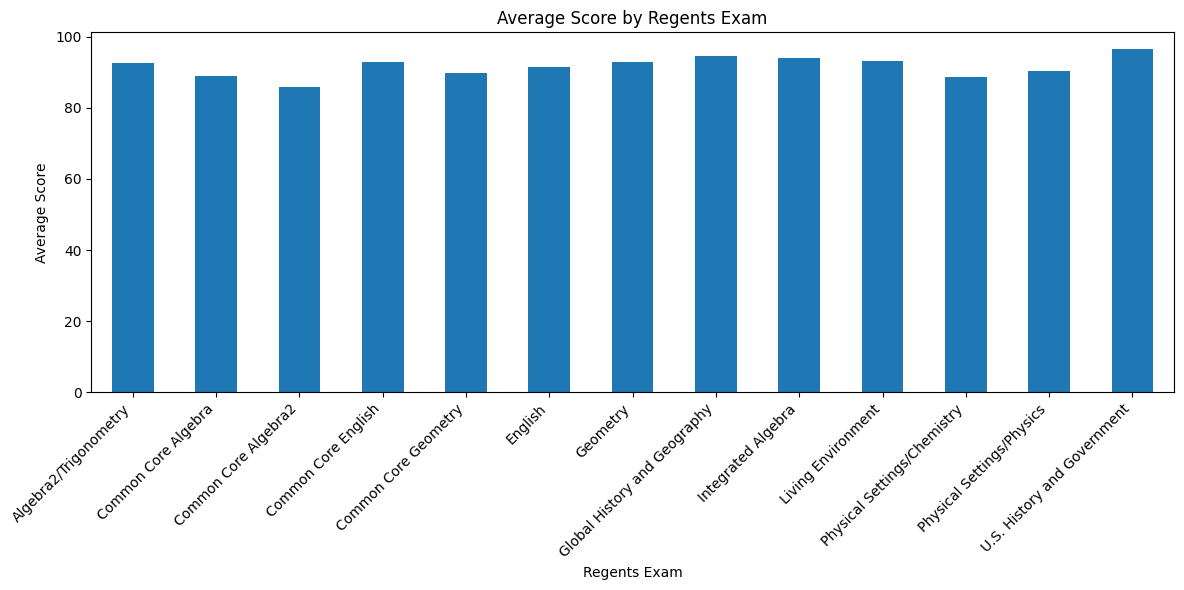

In [130]:
#15 Visualize Average Scores by Regents Exam
exam_average = school_data.groupby('Regents Exam')['Mean Score'].mean()
#Create a bar Chart of teh average score for each regent exam
exam_average.plot(kind='bar', figsize=(12, 6))
plt.title('Average Score by Regents Exam')
plt.xlabel('Regents Exam')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The bar Chart Compares the averages scores across the different Regents exams for the selected school. The results show that performance varies by exam. Some Regents exams have higher average scores than others, makinf it easy to identify the school strongest and weaker subject areas.

In [131]:
#16- Analyze year's Performance
#Calculate the average Regents score for each year
yearly_average_score = school_data.groupby('Year')['Mean Score'].mean()
round(yearly_average_score, 2)

,Mean Score
Year,
2015,91.98
2016,91.23
2017,91.90


The score stayes fairly consistent across the three years, with a small decrease in 2016 followed by an increase in 2017.

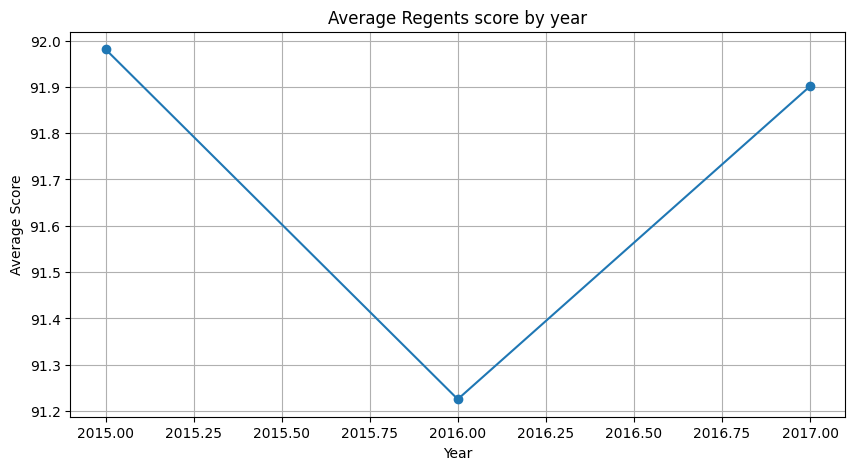

In [132]:
#17- Visualize  Performance by year
#Create a line chart to show average scores by year
yearly_average_score.plot(kind='line', marker='o', figsize=(10, 5))
# Add a title and labels
plt.title('Average Regents score by year')
plt.xlabel('Year')
plt.ylabel('Average Score')
# Display The chart
plt.grid(True)
plt.show()

The line chart shows that the average Regents score decreased from 2015 to 2016 and then increased in 2017. Overall, the score remained relatively stable across the three years.

In [133]:
#18- Analyze Number of Students tested
#A- Calculate the total number of students tested for each regents exams.
students_tested=school_data.groupby('Regents Exam')['Total Tested'].sum()
round(students_tested, 2)

#B-Sort from highest to lowest
students_tested=students_tested.sort_values(ascending=False)
round(students_tested, 2)

#C- Displays the results
students_tested

,Total Tested
Regents Exam,
Global History and Geography,12580
Physical Settings/Chemistry,12525
Common Core Geometry,12394
U.S. History and Government,11200
Physical Settings/Physics,10840
Living Environment,8524
Algebra2/Trigonometry,8335
Common Core English,8260
Common Core Algebra2,7905


This is the records of students by regents exam and the total of students tested.

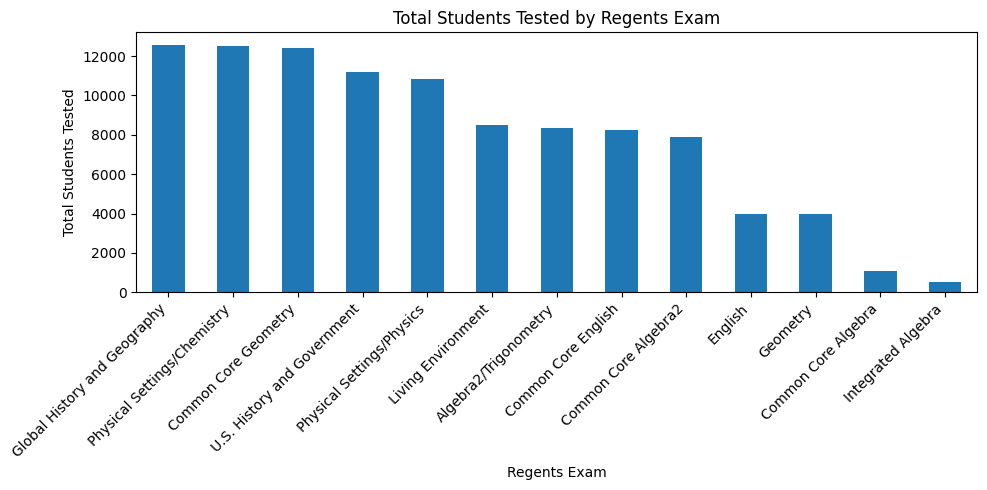

In [134]:
#19- Visualization of students tested.
# make a bar Chart of the total students tested by regents exam
students_tested.plot(kind='bar', figsize=(10, 5))

# Add title and labels
plt.title('Total Students Tested by Regents Exam')
plt.xlabel('Regents Exam')
plt.ylabel('Total Students Tested')

# make exam names easy to read
plt.xticks(rotation=45, ha='right')

#Adjust the layout
plt.tight_layout()

#Display the chart
plt.show()

# Display the chart
plt.show()

This chart compares the total number of students tested across the different regents exams. Some exams were taken by more students than others, showing differences in student participation across subjects.

In [135]:
#20 Analyze students scoring 65 or above
#Convert Percent Scoring 65 or Above to numeric
school_data['Percent Scoring 65 or Above'] = pd.to_numeric(school_data['Percent Scoring 65 or Above'], errors='coerce')

# A- Calculate  the average percentage of students scoring 65 or above
passing_rate=(school_data.groupby('Regents Exam')['Percent Scoring 65 or Above'].mean())
passing_rate=passing_rate.sort_values(ascending=False)
round(passing_rate, 2)


/tmp/ipykernel_1706/3374910043.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  school_data['Percent Scoring 65 or Above'] = pd.to_numeric(school_data['Percent Scoring 65 or Above'], errors='coerce')


,Percent Scoring 65 or Above
Regents Exam,
Common Core Algebra,100.00
Integrated Algebra,100.00
Living Environment,100.00
English,100.00
Global History and Geography,99.94
Common Core Geometry,99.86
U.S. History and Government,99.77
Common Core Algebra2,99.73
Physical Settings/Chemistry,99.62


Fix the warning

In [136]:
#Create an independant copy of the selected school's data
selected_school_data = school_data.copy()

#Convert the oercentage column to numeric
selected_school_data['Percent Scoring 65 or Above'] = pd.to_numeric(selected_school_data['Percent Scoring 65 or Above'], errors='coerce')


In [137]:
#Calculate again
#Calculate the average percentage scoring 65 or above by regents exam
passing_rate = selected_school_data.groupby('Regents Exam')['Percent Scoring 65 or Above'].mean()
passing_rate = passing_rate.sort_values(ascending=False)
round(passing_rate, 2)

,Percent Scoring 65 or Above
Regents Exam,
Common Core Algebra,100.00
Integrated Algebra,100.00
Living Environment,100.00
English,100.00
Global History and Geography,99.94
Common Core Geometry,99.86
U.S. History and Government,99.77
Common Core Algebra2,99.73
Physical Settings/Chemistry,99.62


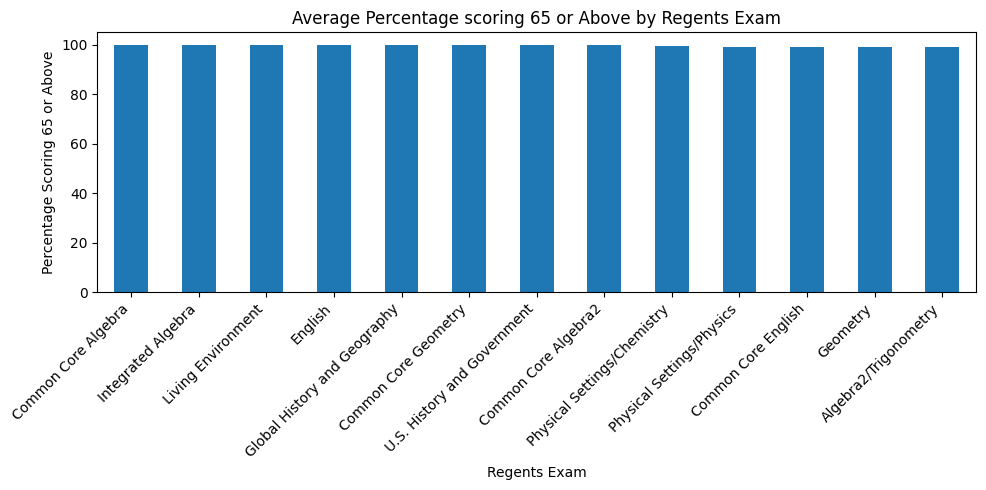

In [138]:
#21- Visualization of Passing Rate
#Create a bar chart of te=he average passing rate
passing_rate.plot(kind='bar', figsize=(10, 5))

#Add title and labels
plt.title('Average Percentage scoring 65 or Above by Regents Exam')
plt.xlabel('Regents Exam')
plt.ylabel('Percentage Scoring 65 or Above')

#Make exam names easy to read
plt.xticks(rotation=45, ha='right')

#Adjust the layout
plt.tight_layout()

#Display the chart
plt.show()

The graph shows that the percentage of students scoring 65 or above is high across the regents exams. Although the passing rates vary by subject, the results show strong performance across the difference exams.

In [139]:
#21- Analyze students scoring 80 or Above
#Convert Percentage column to numeric
school_data['Percent Scoring 80 or Above'] = pd.to_numeric(
school_data['Percent Scoring 80 or Above'],
errors='coerce'
)

# Calculate the average percentage scoring 80 or above by Regents exam
high_score_rate = school_data.groupby('Regents Exam')['Percent Scoring 80 or Above'].mean()

# Sort from highest to lowest
high_score_rate = high_score_rate.sort_values(ascending=False)

# Display the results rounded to two decimal places
round(high_score_rate, 2)


/tmp/ipykernel_1706/4203869730.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  school_data['Percent Scoring 80 or Above'] = pd.to_numeric(


,Percent Scoring 80 or Above
Regents Exam,
Integrated Algebra,100.00
Living Environment,99.93
U.S. History and Government,99.52
Global History and Geography,99.18
Geometry,97.26
Common Core English,97.14
English,96.97
Common Core Geometry,93.90
Algebra2/Trigonometry,93.81


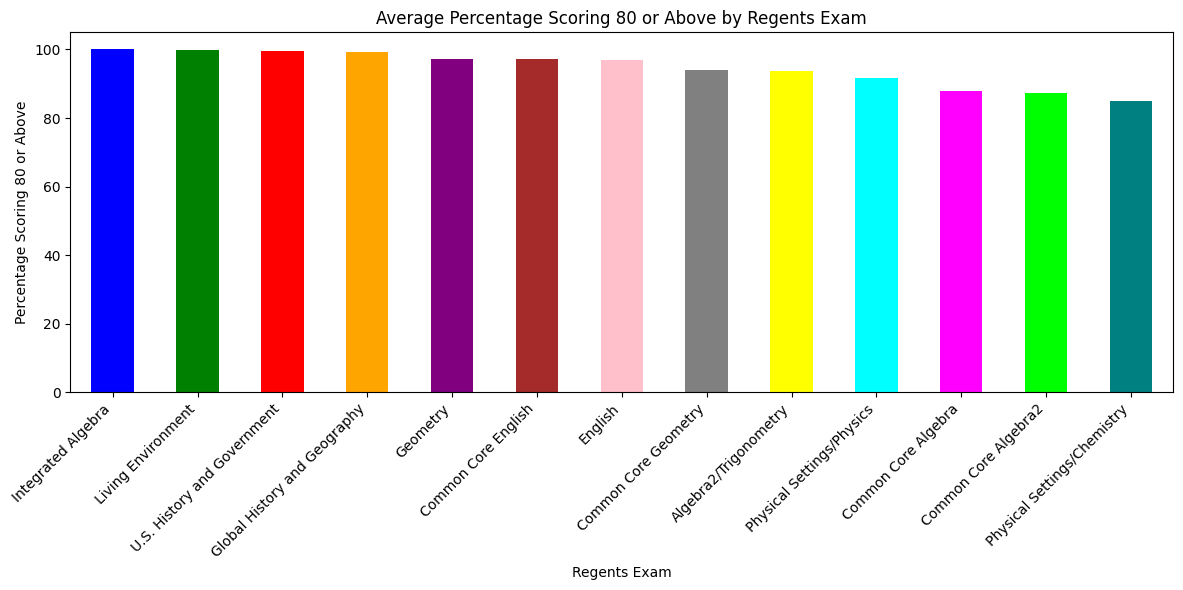

In [140]:
#22- Visualization of High Score Rate

#Create a list of colors
colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown', 'pink', 'gray', 'yellow', 'cyan','magenta', 'lime', 'teal']
#Create a bar chart with different colors
high_score_rate.plot(kind='bar', figsize=(12, 6),
color=colors)

# Add title and labels
plt.title('Average Percentage Scoring 80 or Above by Regents Exam')
plt.xlabel('Regents Exam')
plt.ylabel('Percentage Scoring 80 or Above')

# Make the exam names easier to read
plt.xticks(rotation=45, ha='right')

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()


This bar chart compare the percentage of students scoring 80 or above across the different regents exams. Some subjects have higher percentages of high-scoring students than others, showing differences in performance across subjects.

The graph shows that the percentage

In [141]:
#23-Final Summary Statistics
#Create Summary statistics for the Selected school
school_data[['Mean Score', 'Total Tested', 'Percent Scoring 65 or Above', 'Percent Scoring 80 or Above']].describe().round(2)

,Mean Score,Total Tested,Percent Scoring 65 or Above,Percent Scoring 80 or Above
count,270.00,361.00,270.00,270.00
mean,91.71,282.75,99.64,94.21
std,3.36,287.06,1.36,8.40
min,81.10,1.00,83.30,50.00
25%,89.32,19.00,99.70,92.22
50%,92.50,173.00,100.00,97.60
75%,94.00,536.00,100.00,100.00
max,97.40,909.00,100.00,100.00


The Summary Statistics provide an overall view of the selected school's Regents exam performance. The table shows the number of observations, average, standard deviation, minimum, maximum and quartiles for the main variables. Theses statistics helps summarize students performance and participation in the regents exams.

**FINAL CONCLUSION**

This project analyzed Regents exam performance for the selected NYC public school.

The analysis examined average exam scores, performance across different Regents exams, changes in scores by year, the number of students tested, and the percentages of students scoring 65 or above and 80 or above.

The charts and summary statistics showed differences in student performance across subjects and over time. Overall, this project demonstrates how Python, Pandas, and Matplotlib can be used to clean, analyze, and visualize educational data.